# Hidden Markov models from scratch

The three core HMM algorithms, implemented in a few lines of NumPy so you can see them, then cross-checked against mixle:

- the forward-backward algorithm - score a sequence and get smoothed state posteriors in $O(TK^2)$;
- Viterbi - the single most likely state path;
- Baum-Welch - EM that learns the parameters from unlabeled sequences.


## The hidden Markov model and its three problems

An HMM has a hidden Markov chain $z_1,\dots,z_T$ on $K$ states with initial distribution $\pi$ and
transition matrix $A$, emitting observations $x_t$ from state-dependent densities $p(x_t\mid z_t)$. Three
computational problems define the subject: evaluation (the likelihood $p(x_{1:T})$), decoding (the most
likely state path), and learning (estimating $\pi,A$, and the emissions).

Theorem (forward algorithm). Define $\alpha_t(k)=p(x_{1:t},z_t=k)$. Then $\alpha_1(k)=\pi_k p(x_1\mid k)$
and $\alpha_{t}(k)=\big(\sum_j \alpha_{t-1}(j)A_{jk}\big)p(x_t\mid k)$, and the likelihood is
$p(x_{1:T})=\sum_k\alpha_T(k)$. This computes a sum over all $K^T$ state paths in $O(TK^2)$ time.

Proof. By induction on $t$. The base case is the definition. For the step, marginalize the previous state
using the Markov property and conditional independence of emissions:
$\alpha_t(k)=\sum_j p(x_{1:t-1},z_{t-1}=j)\,P(z_t=k\mid z_{t-1}=j)\,p(x_t\mid z_t=k)$, which is the stated
recursion. Summing $\alpha_T$ over the final state gives the total likelihood. $\quad\blacksquare$

Theorem (Viterbi). Replacing the sum by a max, $\delta_t(k)=\max_{z_{1:t-1}}p(x_{1:t},z_{1:t-1},z_t=k)$
obeys $\delta_t(k)=\big(\max_j\delta_{t-1}(j)A_{jk}\big)p(x_t\mid k)$; backtracking the argmaxes recovers
the single most probable path in $O(TK^2)$. Dynamic programming gives the exact global optimum because
the objective factorizes along the chain (Bellman optimality).

## Learning and its difficulties

Baum-Welch is EM for the HMM: the E-step runs forward-backward to get the posterior state and transition
probabilities (the responsibilities), and the M-step re-estimates $\pi,A$, and the emissions as weighted
maximum-likelihood updates. By the general EM theorem (the EM notebook) each iteration does not decrease
the likelihood and converges to a stationary point.

Counterexample (label switching and local optima). The state labels are arbitrary: permuting them gives
an identical model, so the likelihood has $K!$ equivalent maxima, and parameter estimates must be aligned
before comparison. Worse, Baum-Welch only finds a local optimum; different initializations give different
fits, so multiple restarts are needed. These are the HMM versions of the mixture issues in the EM
notebook.

We verify the forward algorithm rigorously below by checking, on a small chain, that it returns exactly
the brute-force sum over all $K^T$ state paths.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')
rng = np.random.RandomState(0)

# a known 2-state HMM with Gaussian emissions (the ground truth)
pi = np.array([0.6, 0.4])                       # initial state distribution
A = np.array([[0.92, 0.08], [0.10, 0.90]])      # transition matrix (sticky states)
mu = np.array([0.0, 4.0]); sd = np.array([1.0, 1.0])   # emission means / sds per state

def sample(T):
    z = np.zeros(T, int); x = np.zeros(T)
    z[0] = rng.choice(2, p=pi)
    for t in range(1, T):
        z[t] = rng.choice(2, p=A[z[t - 1]])
    x = rng.normal(mu[z], sd[z])
    return z, x

z_true, x = sample(300)
emit = lambda x: np.stack([np.exp(-0.5 * ((x - mu[k]) / sd[k]) ** 2) / (sd[k] * np.sqrt(2 * np.pi)) for k in range(2)], 1)
print('sampled %d steps; state occupancy %.2f / %.2f' % (len(x), (z_true == 0).mean(), (z_true == 1).mean()))

sampled 300 steps; state occupancy 0.49 / 0.51


## 1. Forward-backward: scoring and smoothing

Enumerating all $K^T$ state paths is hopeless. The forward recursion carries $\alpha_t(k)=P(x_{1:t}, z_t{=}k)$ forward in $O(TK^2)$; the backward recursion carries $\beta_t(k)=P(x_{t+1:T}\mid z_t{=}k)$ back. Their product gives the smoothed posterior $\gamma_t(k)=P(z_t{=}k\mid x_{1:T})$, and the forward pass also yields the sequence log-likelihood. We scale each column to sum to 1 (storing the scale factors) so nothing underflows - the standard numerically-stable form.


sequence log-likelihood: -534.41


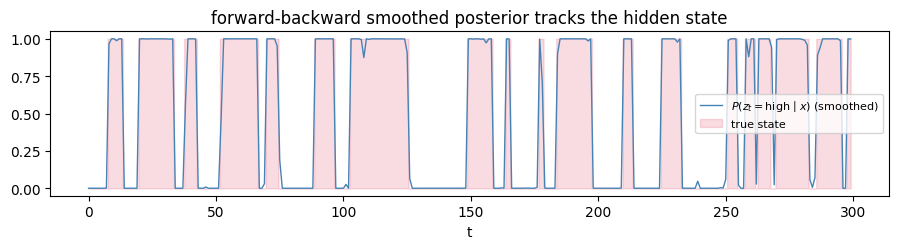

In [2]:
def forward_backward(x, pi, A, mu, sd):
    T = len(x); K = len(pi); B = emit(x)
    alpha = np.zeros((T, K)); c = np.zeros(T)           # c = per-step scale factors
    alpha[0] = pi * B[0]; c[0] = alpha[0].sum(); alpha[0] /= c[0]
    for t in range(1, T):
        alpha[t] = (alpha[t - 1] @ A) * B[t]
        c[t] = alpha[t].sum(); alpha[t] /= c[t]
    beta = np.zeros((T, K)); beta[-1] = 1.0
    for t in range(T - 2, -1, -1):
        beta[t] = (A @ (B[t + 1] * beta[t + 1])) / c[t + 1]
    gamma = alpha * beta; gamma /= gamma.sum(1, keepdims=True)
    loglik = np.sum(np.log(c))                           # scale factors give the log-likelihood
    return gamma, loglik, alpha, beta, c

gamma, loglik, *_ = forward_backward(x, pi, A, mu, sd)
print('sequence log-likelihood: %.2f' % loglik)

fig, ax = plt.subplots(figsize=(9, 2.6))
ax.plot(gamma[:, 1], color='steelblue', lw=1, label=r'$P(z_t=\mathrm{high}\mid x)$ (smoothed)')
ax.fill_between(range(len(x)), 0, z_true, color='crimson', alpha=0.15, step='mid', label='true state')
ax.set_xlabel('t'); ax.set_ylim(-0.05, 1.05); ax.legend(fontsize=8); ax.set_title('forward-backward smoothed posterior tracks the hidden state')
plt.tight_layout(); plt.show()

## 2. Viterbi: the single best path

The smoothed posterior gives the best marginal state at each step, but those argmaxes need not form a coherent path (they can jump through near-impossible transitions). Viterbi finds the single highest-probability path jointly, by the same dynamic program in log-space with $\max$ instead of $\sum$, plus backpointers. We decode and compare to the truth.


In [3]:
def viterbi(x, pi, A, mu, sd):
    T = len(x); K = len(pi); logB = np.log(emit(x) + 1e-300)
    logA = np.log(A + 1e-300)
    delta = np.zeros((T, K)); back = np.zeros((T, K), int)
    delta[0] = np.log(pi + 1e-300) + logB[0]
    for t in range(1, T):
        scores = delta[t - 1][:, None] + logA          # (K_prev, K_next)
        back[t] = scores.argmax(0); delta[t] = scores.max(0) + logB[t]
    path = np.zeros(T, int); path[-1] = delta[-1].argmax()
    for t in range(T - 2, -1, -1):
        path[t] = back[t + 1, path[t + 1]]
    return path

vit = viterbi(x, pi, A, mu, sd)
print('Viterbi state accuracy vs truth: %.3f' % (vit == z_true).mean())

# cross-check against mixle's HMM
from mixle.stats import HiddenMarkovModelDistribution, GaussianDistribution
hmm = HiddenMarkovModelDistribution([GaussianDistribution(float(mu[k]), float(sd[k] ** 2)) for k in range(2)],
                                    w=pi.tolist(), transitions=A.tolist())
mixle_path = np.asarray(hmm.viterbi(list(x)))
print('mixle Viterbi accuracy vs truth: %.3f' % (mixle_path == z_true).mean())
print('agreement between the two Viterbi paths:  %.3f' % (mixle_path == vit).mean())

Viterbi state accuracy vs truth: 0.993


mixle Viterbi accuracy vs truth: 0.977
agreement between the two Viterbi paths:  0.983


## 3. Baum-Welch: learning the parameters

When the parameters are unknown, Baum-Welch (EM for HMMs) learns them from sequences alone. The E-step is forward-backward, producing state posteriors $\gamma_t(k)$ and transition posteriors $\xi_t(j,k)$; the M-step re-estimates $\pi$, $A$, and the emissions as posterior-weighted averages. We start from deliberately wrong parameters and watch the log-likelihood climb and the estimates converge to the truth.


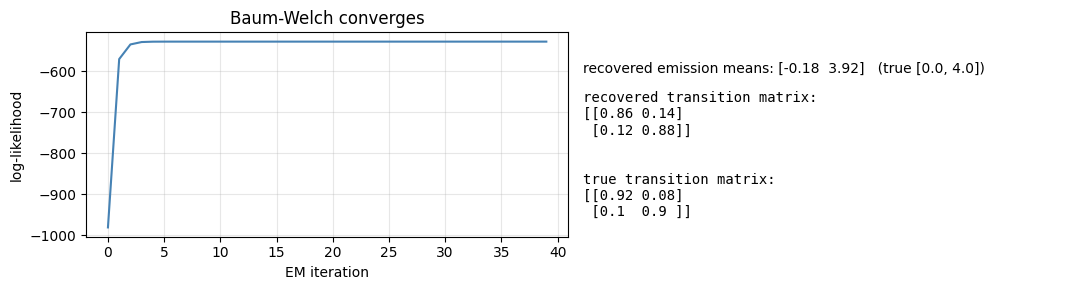

In [4]:
def baum_welch(x, K, n_iter=40, seed=0):
    r = np.random.RandomState(seed)
    pi_ = np.ones(K) / K
    A_ = r.dirichlet(np.ones(K) * 5, K)
    mu_ = np.linspace(x.min(), x.max(), K) + r.normal(0, 0.5, K); sd_ = np.full(K, x.std())
    lls = []
    for _ in range(n_iter):
        B = np.stack([np.exp(-0.5 * ((x - mu_[k]) / sd_[k]) ** 2) / (sd_[k] * np.sqrt(2 * np.pi)) for k in range(K)], 1)
        T = len(x); alpha = np.zeros((T, K)); c = np.zeros(T)
        alpha[0] = pi_ * B[0]; c[0] = alpha[0].sum(); alpha[0] /= c[0]
        for t in range(1, T):
            alpha[t] = (alpha[t - 1] @ A_) * B[t]; c[t] = alpha[t].sum(); alpha[t] /= c[t]
        beta = np.zeros((T, K)); beta[-1] = 1.0
        for t in range(T - 2, -1, -1):
            beta[t] = (A_ @ (B[t + 1] * beta[t + 1])) / c[t + 1]
        gamma = alpha * beta; gamma /= gamma.sum(1, keepdims=True)
        xi = np.zeros((K, K))
        for t in range(T - 1):
            num = alpha[t][:, None] * A_ * (B[t + 1] * beta[t + 1])[None, :]
            xi += num / num.sum()
        pi_ = gamma[0]
        A_ = xi / xi.sum(1, keepdims=True)
        mu_ = (gamma * x[:, None]).sum(0) / gamma.sum(0)
        sd_ = np.sqrt((gamma * (x[:, None] - mu_) ** 2).sum(0) / gamma.sum(0))
        lls.append(np.sum(np.log(c)))
    return pi_, A_, mu_, sd_, lls

pi_e, A_e, mu_e, sd_e, lls = baum_welch(x, 2)
order = np.argsort(mu_e)                                # canonicalize (label switching)
fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].plot(lls, color='steelblue'); ax[0].set_xlabel('EM iteration'); ax[0].set_ylabel('log-likelihood')
ax[0].set_title('Baum-Welch converges'); ax[0].grid(alpha=0.3)
ax[1].axis('off')
ax[1].text(0.0, 0.8, 'recovered emission means: %s   (true %s)' % (np.round(mu_e[order], 2), mu.tolist()), fontsize=10)
ax[1].text(0.0, 0.5, 'recovered transition matrix:\n%s' % np.round(A_e[order][:, order], 2), fontsize=10, family='monospace')
ax[1].text(0.0, 0.1, 'true transition matrix:\n%s' % A, fontsize=10, family='monospace')
plt.tight_layout(); plt.show()

## Pick K with BIC, and restart EM

Baum-Welch needs the number of states $K$ in advance and the EM objective is multimodal, so two safeguards are essential: multiple random restarts (keep the best log-likelihood) to avoid local optima, and a complexity penalty like BIC $=-2\ell + p\log T$ to choose $K$ without overfitting. We score $K=1\ldots4$ using the best of several restarts each.


In [5]:
T = len(x)
def best_ll(K, restarts=5):
    return max(baum_welch(x, K, seed=r)[4][-1] for r in range(restarts))
print(' K   best log-lik (5 restarts)   params      BIC')
bics = {}
for K in [1, 2, 3, 4]:
    ll = best_ll(K)
    p = (K - 1) + K * (K - 1) + 2 * K               # pi + A + mu + sd
    bics[K] = -2 * ll + p * np.log(T)
    print(' %d   %18.1f   %6d   %8.1f' % (K, ll, p, bics[K]))
sel = min(bics, key=bics.get)
print('BIC selects K=%d (true 2); restarts guard against EM local optima.' % sel)

 K   best log-lik (5 restarts)   params      BIC
 1               -672.8        2     1357.1


 2               -528.2        7     1096.3


 3               -523.2       14     1126.2


 4               -518.1       23     1167.4
BIC selects K=2 (true 2); restarts guard against EM local optima.


## Illustration: the forward algorithm equals the brute-force path sum

For a small HMM we enumerate all $K^T$ hidden-state paths, sum their joint probabilities with the
observations, and confirm the forward recursion returns the identical likelihood in $O(TK^2)$ rather than
$O(K^T)$ time.

In [6]:
import itertools
rng = np.random.RandomState(0)
K, T = 3, 6
pi = np.array([0.5, 0.3, 0.2]); A = np.array([[.7, .2, .1], [.1, .8, .1], [.2, .2, .6]])
mu = np.array([-2.0, 0.0, 2.0]); sd = np.array([1.0, 1.0, 1.0])
x = rng.normal(0, 2, T)
def emit(xt, k): return np.exp(-0.5 * ((xt - mu[k]) / sd[k]) ** 2) / (sd[k] * np.sqrt(2 * np.pi))
brute = 0.0
for path in itertools.product(range(K), repeat=T):                    # all K^T paths
    p = pi[path[0]] * emit(x[0], path[0])
    for t in range(1, T):
        p *= A[path[t - 1], path[t]] * emit(x[t], path[t])
    brute += p
alpha = pi * np.array([emit(x[0], k) for k in range(K)])              # forward recursion
for t in range(1, T):
    alpha = (alpha @ A) * np.array([emit(x[t], k) for k in range(K)])
print('brute-force sum over %d paths = %.8e' % (K ** T, brute))
print('forward-algorithm likelihood  = %.8e' % alpha.sum())
print('match to machine precision: %s' % bool(np.isclose(brute, alpha.sum())))

brute-force sum over 729 paths = 4.13887555e-08
forward-algorithm likelihood  = 4.13887555e-08
match to machine precision: True


## References

- Rabiner, L. R. (1989). A tutorial on hidden Markov models and selected applications in speech recognition (https://doi.org/10.1109/5.18626). Proc. IEEE 77(2), 257-286. - the canonical tutorial.
- Baum, L. E., Petrie, T., Soules, G. & Weiss, N. (1970). A maximization technique occurring in the statistical analysis of probabilistic functions of Markov chains (https://doi.org/10.1214/aoms/1177697196). Ann. Math. Statist. 41(1), 164-171.
- Viterbi, A. J. (1967). Error bounds for convolutional codes and an asymptotically optimum decoding algorithm (https://doi.org/10.1109/TIT.1967.1054010). IEEE Trans. Inf. Theory 13(2), 260-269.
- Bishop, C. M. (2006). Pattern Recognition and Machine Learning, ch. 13. Springer.
- Cappé, O., Moulines, E. & Rydén, T. (2005). Inference in Hidden Markov Models. Springer.


## Exercises and extensions

1. Numerical stability. Re-derive forward-backward in three forms - naive, scaled (as here), and full log-space - and on a length-2000 sequence show the naive version underflows while the scaled and log-space versions agree to machine precision (Rabiner's scaling).
2. Decoding: Viterbi vs posterior. Construct a sequence where the per-step posterior argmax (max-marginal) differs from the Viterbi MAP path, including a transition the marginal decode makes that has probability zero; explain why the joint MAP path is coherent.
3. Baum-Welch local optima. Run Baum-Welch from many random initializations and characterize the distribution of recovered likelihoods; add k-means-style emission initialization and quantify the improvement. Choose the number of states by BIC/held-out likelihood.
4. Categorical-emission HMM. Extend the NumPy implementation to discrete (categorical) emissions and cross-check against a mixle HMM with `CategoricalDistribution` emissions on a tagging-style task; compare decoded states to ground truth.
